In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Dense, Dropout, Flatten,LSTM,GRU
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error ,mean_absolute_error

In [2]:
clns=["unit_number","time_cycles","op_setting_1","op_setting_2","op_setting_3"]+[f"sensor{i}" for i in range(1,22)]
fe=["op_setting_1","op_setting_2","op_setting_3"]+[f"sensor{i}" for i in range(1, 22)]

print(len(clns))

26


In [3]:
train_1=pd.read_csv("./nasa/train_FD001.txt",sep=r"\s+",header=None,names=clns)

In [4]:
test_1=pd.read_csv("./nasa/test_FD001.txt",sep=r"\s+",header=None,names=clns)

In [5]:
rul_1=pd.read_csv("./nasa/rul_FD001.txt",sep=r"\s+",header=None,names=["rul"])

In [6]:
mx_c=train_1.groupby("unit_number")["time_cycles"].transform("max")
train_1["rul"]=(mx_c-train_1["time_cycles"]).clip(upper=125)

In [7]:
sc=MinMaxScaler()
train_1[fe]=sc.fit_transform(train_1[fe])
test_1[fe]=sc.transform(test_1[fe])

In [8]:
uni=train_1["unit_number"].unique()
np.random.seed(42)
np.random.shuffle(uni)

n_train=int(len(uni)* 0.8)
train_uni=uni[:n_train]
val_uni=uni[n_train:]

In [9]:
s_l=30
xl=[]
yl=[]
for i in train_uni:
    en_data=train_1[train_1["unit_number"]==i].sort_values("time_cycles")
    data=en_data[fe].values
    rul_val=en_data["rul"].values
    for j in range(0,len(data)-s_l+1):
        wi=data[j:j+s_l]
        tar=rul_val[j+s_l-1]
        xl.append(wi)
        yl.append(tar)
x_train=np.array(xl)
y_train=np.array(yl)

In [10]:
xl_val,yl_val=[],[]
for i in val_uni:
    en_data=train_1[train_1["unit_number"]==i].sort_values("time_cycles")
    data=en_data[fe].values
    rul_val=en_data["rul"].values

    for j in range(len(data)-s_l+1):
        wi=data[j:j+s_l]
        tar=rul_val[j+s_l-1]
        xl_val.append(wi)
        yl_val.append(tar)

x_val=np.array(xl_val)
y_val=np.array(yl_val)

In [11]:
print(len(fe))

24


In [12]:
model=Sequential()
model.add(GRU(64,return_sequences=True,input_shape=(s_l,24)))
model.add(Dropout(0.4))
model.add(GRU(16,return_sequences=False))
model.add(Dropout(0.4))
model.add(Dense(1))

C:\Users\LOQ\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
compile=model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        17,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         3,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,233 (82.94 KB)

 Trainable params: 21,233 (82.94 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
sc2=MinMaxScaler()

y_train_sc=sc2.fit_transform(y_train.reshape(-1, 1))
y_val_sc=sc2.transform(y_val.reshape(-1, 1))

In [16]:
erl=EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True,verbose=1)
ckp=ModelCheckpoint("bst_modelFD001.keras",monitor='val_loss',save_best_only=True,verbose=1)

In [17]:
history=model.fit(x_train,y_train_sc,validation_data=(x_val,y_val_sc),epochs=100,batch_size=32,callbacks=[erl,ckp])

Epoch 1/100
437/439 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0916 - mae: 0.2356
Epoch 1: val_loss improved from None to 0.02901, saving model to bst_modelFD001.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0620 - mae: 0.1964 - val_loss: 0.0290 - val_mae: 0.1413
Epoch 2/100
437/439 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0433 - mae: 0.1668
Epoch 2: val_loss improved from 0.02901 to 0.02581, saving model to bst_modelFD001.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0413 - mae: 0.1630 - val_loss: 0.0258 - val_mae: 0.1249
Epoch 3/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0319 - mae: 0.1433
Epoch 3: val_loss improved from 0.02581 to 0.01713, saving model to bst_modelFD001.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0289 - mae: 0.1362 - val_loss: 0.0171 - val_mae: 0.1057
Epoch 4/100
433/439 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0233 - mae: 0.1219
Epoch 4: val_loss improved from 0.01713 to 0.01587, saving model to bst_modelFD001.k

In [19]:
l_model=load_model("bst_modelFD001.keras")
y_pre_sc=l_model.predict(x_val)
y_pred=sc2.inverse_transform(y_pre_sc)


116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [20]:
Rmse=np.sqrt(mean_squared_error(y_val,y_pred))
mae=mean_absolute_error(y_val,y_pred)

print(f"rmse: {Rmse:.2f}")
print(f"mae: {mae:.2f}")

rmse: 13.39
mae: 9.31


116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


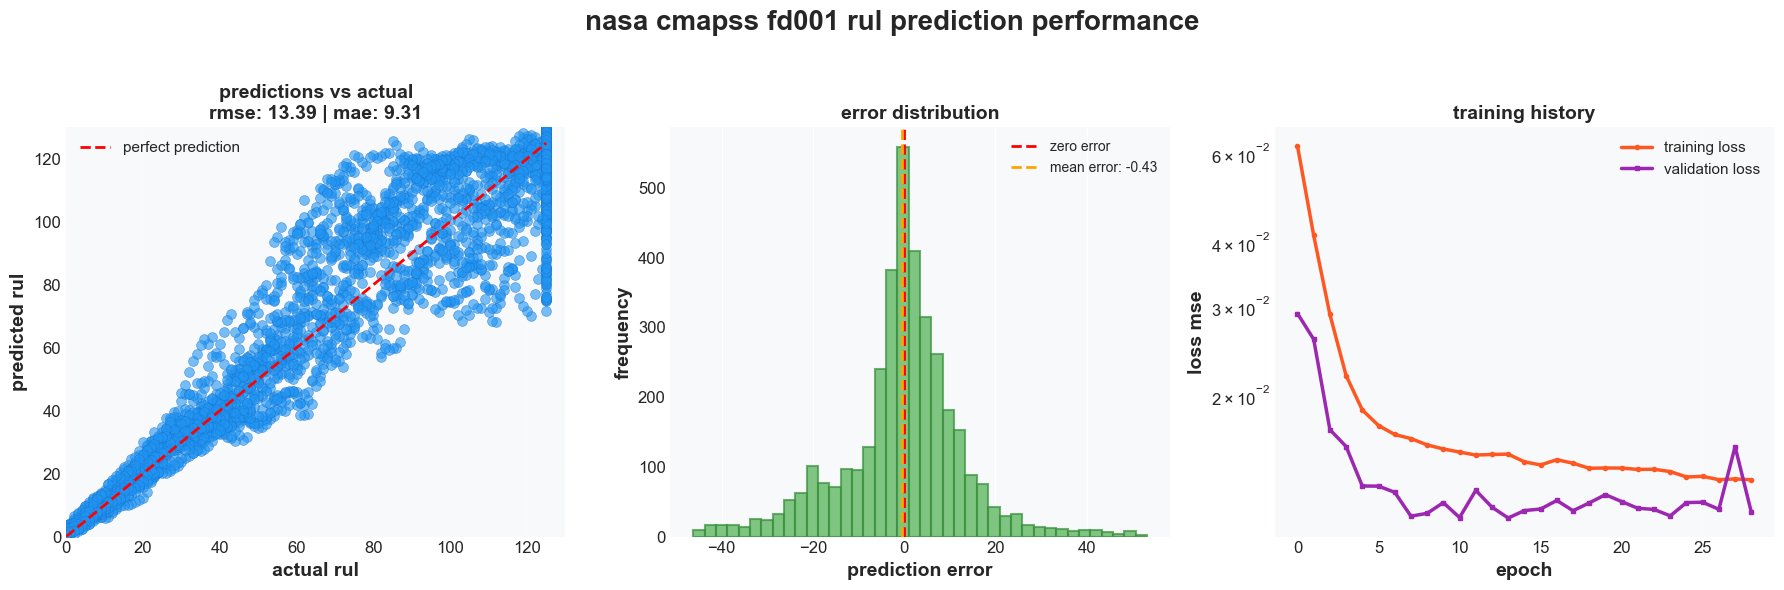

rmse: 13.39 cycles
mae: 9.31 cycles
accuracy: 89.3%


In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.facecolor']='white'
plt.rcParams['axes.facecolor']='#f8f9fa'
plt.rcParams['font.size']=12
plt.rcParams['axes.labelsize']=14
plt.rcParams['axes.titlesize']=16

from tensorflow.keras.models import load_model
bst_model=load_model("bst_modelFD001.keras")
y_pred_sc=bst_model.predict(x_val)
y_pred=sc2.inverse_transform(y_pred_sc).flatten()

rmse=np.sqrt(mean_squared_error(y_val, y_pred))
mae=mean_absolute_error(y_val, y_pred)

fig=plt.figure(figsize=(18, 6))
fig.suptitle('nasa cmapss fd001 rul prediction performance',
             fontsize=20,fontweight='bold',y=0.98)

ax1=plt.subplot(1,3,1)
scatter=ax1.scatter(y_val,y_pred,alpha=0.6,c='#2196F3',
                     edgecolors='#1976D2',s=50,linewidth=0.5)
ax1.plot([0, 125],[0, 125], 'r--',linewidth=2,label='perfect prediction')
ax1.set_xlabel('actual rul',fontweight='bold')
ax1.set_ylabel('predicted rul',fontweight='bold')
ax1.set_title(f'predictions vs actual\nrmse: {rmse:.2f} | mae: {mae:.2f}',
             fontweight='bold',fontsize=14)
ax1.legend(fontsize=11,loc='upper left')
ax1.grid(True,alpha=0.3)
ax1.set_xlim(0,130)
ax1.set_ylim(0,130)

ax2=plt.subplot(1, 3, 2)
errors=y_val- y_pred
ax2.hist(errors,bins=40,color='#4CAF50',alpha=0.7,
        edgecolor='#388E3C',linewidth=1.5)
ax2.axvline(x=0, color='red',linestyle='--',linewidth=2,label='zero error')
ax2.axvline(x=np.mean(errors),color='orange',linestyle='--',
           linewidth=2, label=f'mean error: {np.mean(errors):.2f}')
ax2.set_xlabel('prediction error',fontweight='bold')
ax2.set_ylabel('frequency',fontweight='bold')
ax2.set_title('error distribution',fontweight='bold',fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True,alpha=0.3, axis='y')

ax3=plt.subplot(1,3,3)
ax3.plot(history.history['loss'],label='training loss',
        color='#FF5722',linewidth=2.5,marker='o',markersize=3)
ax3.plot(history.history['val_loss'],label='validation loss',
        color='#9C27B0',linewidth=2.5,marker='s',markersize=3)
ax3.set_xlabel('epoch',fontweight='bold')
ax3.set_ylabel('loss mse',fontweight='bold')
ax3.set_title('training history',fontweight='bold',fontsize=14)
ax3.legend(fontsize=11,loc='upper right')
ax3.grid(True,alpha=0.3)
ax3.set_yscale('log')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"rmse: {rmse:.2f} cycles")
print(f"mae: {mae:.2f} cycles")
print(f"accuracy: {100 * (1 - rmse/125):.1f}%")

In [ ]:
def prepare_data(name,s_l=30,val_ratio=0.2,seed=42):
    clns=["unit_number","time_cycles","op_setting_1","op_setting_2","op_setting_3"]+[f"sensor{i}" for i in range(1,22)]
    fe=["op_setting_1","op_setting_2","op_setting_3"]+[f"sensor{i}" for i in range(1,22)]

    train=pd.read_csv(f"./nasa/train_{name}.txt",sep=r"\s+",header=None,names=clns)
    test=pd.read_csv(f"./nasa/test_{name}.txt",sep=r"\s+", header=None,names=clns)
    rul=pd.read_csv(f"./nasa/RUL_{name}.txt",sep=r"\s+",header=None, names=["rul"])

    mx_c=train.groupby("unit_number")["time_cycles"].transform("max")
    train["rul"]=(mx_c-train["time_cycles"]).clip(upper=125)

    sc=MinMaxScaler()
    train[fe]=sc.fit_transform(train[fe])
    test[fe]=sc.transform(test[fe])

    units=train["unit_number"].unique()
    np.random.seed(seed)
    np.random.shuffle(units)

    n_train=int(len(units)*(1-val_ratio))
    train_uni=units[:n_train]
    val_uni=units[n_train:]

    xl_train,yl_train=[],[]
    for i in train_uni:
        en_data=train[train["unit_number"]==i].sort_values("time_cycles")
        data=en_data[fe].values
        rul_val=en_data["rul"].values

        for j in range(len(data)-s_l+1):
            xl_train.append(data[j:j+s_l])
            yl_train.append(rul_val[j+s_l-1])

    x_train=np.array(xl_train)
    y_train=np.array(yl_train)

    xl_val,yl_val=[],[]
    for i in val_uni:
        en_data=train[train["unit_number"]==i].sort_values("time_cycles")
        data=en_data[fe].values
        rul_val=en_data["rul"].values

        for j in range(len(data)-s_l+1):
            xl_val.append(data[j:j+s_l])
            yl_val.append(rul_val[j+s_l-1])

    x_val=np.array(xl_val)
    y_val=np.array(yl_val)

    return x_train,y_train,x_val,y_val,test,rul,sc